In [1]:
# ==================== 1. IMPORT LIBRARIES ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [2]:
# ==================== 2. LOAD DATASET ====================
df = pd.read_csv("../dataset/customer_churn.csv")

print("✅ Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nPercentage:")
print(round(df['Churn'].value_counts(normalize=True) * 100, 2))

✅ Dataset loaded successfully!
Shape of dataset: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [ ]:
# ==================== 2. LOAD DATASET ====================
df = pd.read_csv("../dataset/customer_churn.csv")

print("✅ Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nPercentage:")
print(round(df['Churn'].value_counts(normalize=True) * 100, 2))

FileNotFoundError: [Errno 2] No such file or directory: 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [4]:
# ==================== 3. DATA PREPROCESSING ====================

# 1. Drop customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

# 2. Fix TotalCharges (it has blank spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 3. Encode categorical columns
from sklearn.preprocessing import LabelEncoder

# List of categorical columns
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# 4. Encode target variable (Churn)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("✅ Preprocessing completed successfully!")
print("Final shape:", df.shape)
print("\nData types after encoding:")
print(df.dtypes)
print("\nFirst 5 rows after preprocessing:")
display(df.head())

✅ Preprocessing completed successfully!
Final shape: (7043, 20)

Data types after encoding:
gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

First 5 rows after preprocessing:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [5]:
# ==================== 4. TRAIN-TEST SPLIT ====================
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Train-Test Split Done!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

✅ Train-Test Split Done!
Training samples: 5634
Testing samples: 1409


In [6]:
# ==================== 5. TRAIN RANDOM FOREST MODEL ====================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


=== Random Forest Performance on Test Data ===
Accuracy  : 0.7821
ROC-AUC   : 0.8337

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.86      0.85      0.85      1035
       Churn       0.59      0.61      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409



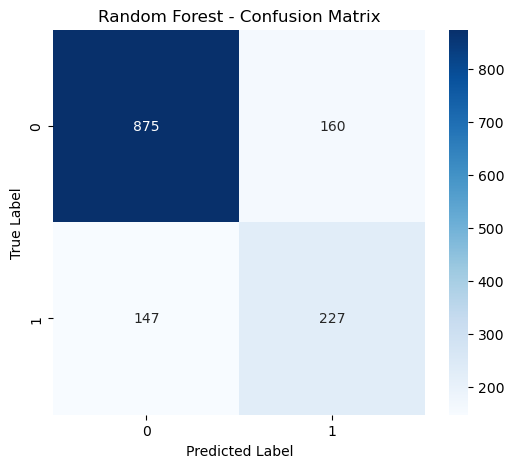

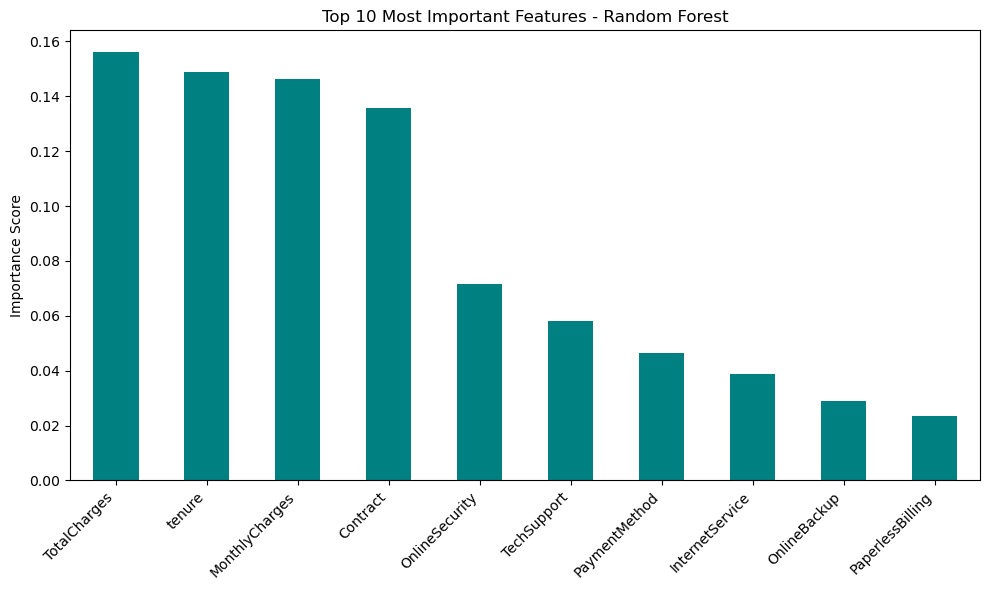

In [7]:
# ==================== 6. MODEL EVALUATION ====================
print("=== Random Forest Performance on Test Data ===")
print("Accuracy  :", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC   :", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion Matrix Plot
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Top 10 Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='teal')
plt.title('Top 10 Most Important Features - Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# ==================== 7. SUMMARY FOR REPORT ====================

print("=== RANDOM FOREST RESULTS - SUMMARY FOR ASSIGNMENT REPORT ===\n")

print("Dataset Used:")
print("- Telco Customer Churn Dataset (Kaggle)")
print("- Total samples: 7043")
print("- Churn Rate: 26.54% (imbalanced)")

print("\nModel Parameters:")
print("- n_estimators = 200")
print("- max_depth = 15")
print("- class_weight = 'balanced' (to handle imbalance)")

print("\nPerformance Metrics:")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

print("\nKey Observations:")
print("- TotalCharges, tenure, and MonthlyCharges are the top 3 most important features.")
print("- Contract type and OnlineSecurity also play significant roles in predicting churn.")
print("- The model handles class imbalance reasonably well due to class_weight='balanced'.")

print("\nLimitations:")
print("- Dataset is moderately imbalanced (73% No Churn).")
print("- No hyperparameter tuning was performed in this version (can be improved).")
print("- Random Forest can sometimes be less interpretable than simpler models.")

print("\n✅ Your Random Forest implementation is complete!")

=== RANDOM FOREST RESULTS - SUMMARY FOR ASSIGNMENT REPORT ===

Dataset Used:
- Telco Customer Churn Dataset (Kaggle)
- Total samples: 7043
- Churn Rate: 26.54% (imbalanced)

Model Parameters:
- n_estimators = 200
- max_depth = 15
- class_weight = 'balanced' (to handle imbalance)

Performance Metrics:
Accuracy  : 0.7821
ROC-AUC   : 0.8337

Key Observations:
- TotalCharges, tenure, and MonthlyCharges are the top 3 most important features.
- Contract type and OnlineSecurity also play significant roles in predicting churn.
- The model handles class imbalance reasonably well due to class_weight='balanced'.

Limitations:
- Dataset is moderately imbalanced (73% No Churn).
- No hyperparameter tuning was performed in this version (can be improved).
- Random Forest can sometimes be less interpretable than simpler models.

✅ Your Random Forest implementation is complete!


In [9]:
import os
print("Current folder location:")
print(os.getcwd())

Current folder location:
C:\Users\amash\Untitled Folder 1


In [10]:
import os
print("Python is currently standing in:")
print(os.getcwd())

Python is currently standing in:
C:\Users\amash\Untitled Folder 1
